In [ ]:
#warehouse classifier

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.datasets import fashion_mnist
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import time
import os
from dotenv import load_dotenv
from databricks import sql

load_dotenv()

host      = os.getenv("DATABRICKS_HOST")
http_path = os.getenv("DATABRICKS_HTTP_PATH")
token     = os.getenv("DATABRICKS_TOKEN")

# ── Load already-saved model ─────────────────────────────────────────────────
full_model = load_model("models/fashion_cnn.keras")   # ← already exists ✅

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

@tf.function
def run_model(x):
    return full_model(x, training=False)

# Warm up
_ = run_model(np.zeros((1, 28, 28, 1), dtype=np.float32))
print("✅ Model loaded and ready")


✅ Model loaded and ready


In [2]:
(_, _), (X_test, y_test) = fashion_mnist.load_data()

def classify_item(img_array):
    """Classify a single 28x28 grayscale array."""
    arr   = (img_array / 255.0).astype(np.float32).reshape(1, 28, 28, 1)
    preds = run_model(arr).numpy()[0]
    idx   = preds.argmax()
    return class_names[idx], float(preds[idx])

# Simulate 20 items coming off the belt
np.random.seed(42)
belt_indices = np.random.choice(len(X_test), 20, replace=False)

results = []
print("🏭 Conveyor Belt Scanner — Processing Items\n")
print(f"{'Item':<6} {'True Label':<14} {'Predicted':<14} {'Confidence':<12} {'Status'}")
print("─" * 60)

for i, idx in enumerate(belt_indices):
    label, conf = classify_item(X_test[idx])
    true_label  = class_names[y_test[idx]]
    status      = "✅" if label == true_label else "❌"

    results.append({
        "item_no"        : i + 1,
        "true_label"     : true_label,
        "predicted_label": label,
        "confidence"     : round(conf, 4),
        "correct"        : label == true_label,
        "scan_time_ms"   : None   # filled below
    })

    print(f"{i+1:<6} {true_label:<14} {label:<14} {conf:.1%}{'':>4} {status}")

# Summary
correct = sum(r["correct"] for r in results)
print(f"\n✅ {correct}/20 correct | Accuracy: {correct/20:.0%}")


🏭 Conveyor Belt Scanner — Processing Items

Item   True Label     Predicted      Confidence   Status
────────────────────────────────────────────────────────────
1      Shirt          Shirt          90.2%     ✅
2      Dress          Dress          99.9%     ✅
3      T-shirt        Shirt          56.6%     ❌
4      Sandal         Ankle boot     96.4%     ❌
5      Pullover       Pullover       98.8%     ✅
6      Sandal         Sandal         100.0%     ✅
7      Ankle boot     Ankle boot     100.0%     ✅
8      Sandal         Sandal         100.0%     ✅
9      Shirt          Shirt          69.7%     ✅
10     Dress          Dress          100.0%     ✅
11     Bag            Bag            100.0%     ✅
12     Trouser        Trouser        100.0%     ✅
13     T-shirt        T-shirt        73.3%     ✅
14     Dress          Dress          99.1%     ✅
15     Ankle boot     Sandal         58.8%     ❌
16     Shirt          Shirt          90.3%     ✅
17     Sneaker        Sneaker        97.0%     ✅

In [3]:
# Measure how fast the model can scan items (ms per item)
times = []

for idx in belt_indices:
    arr = (X_test[idx] / 255.0).astype(np.float32).reshape(1, 28, 28, 1)
    start = time.perf_counter()
    _     = run_model(arr)
    end   = time.perf_counter()
    times.append((end - start) * 1000)

# Fill scan times into results
for i, t in enumerate(times):
    results[i]["scan_time_ms"] = round(t, 2)

avg_ms = np.mean(times)
print(f"⚡ Avg scan time : {avg_ms:.2f} ms per item")
print(f"⚡ Items/second  : {1000/avg_ms:.0f} items/sec")
print(f"⚡ Items/hour    : {(1000/avg_ms)*3600:,.0f} items/hour")


⚡ Avg scan time : 1.79 ms per item
⚡ Items/second  : 558 items/sec
⚡ Items/hour    : 2,009,148 items/hour


/var/folders/rs/k45t2h054lqgqjn4nhrz30p00000gp/T/ipykernel_6717/2556981432.py:21: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/rs/k45t2h054lqgqjn4nhrz30p00000gp/T/ipykernel_6717/2556981432.py:22: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  plt.savefig("warehouse_scan.png", dpi=150, bbox_inches="tight")
/Users/sunerawanni/Desktop/databricks/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


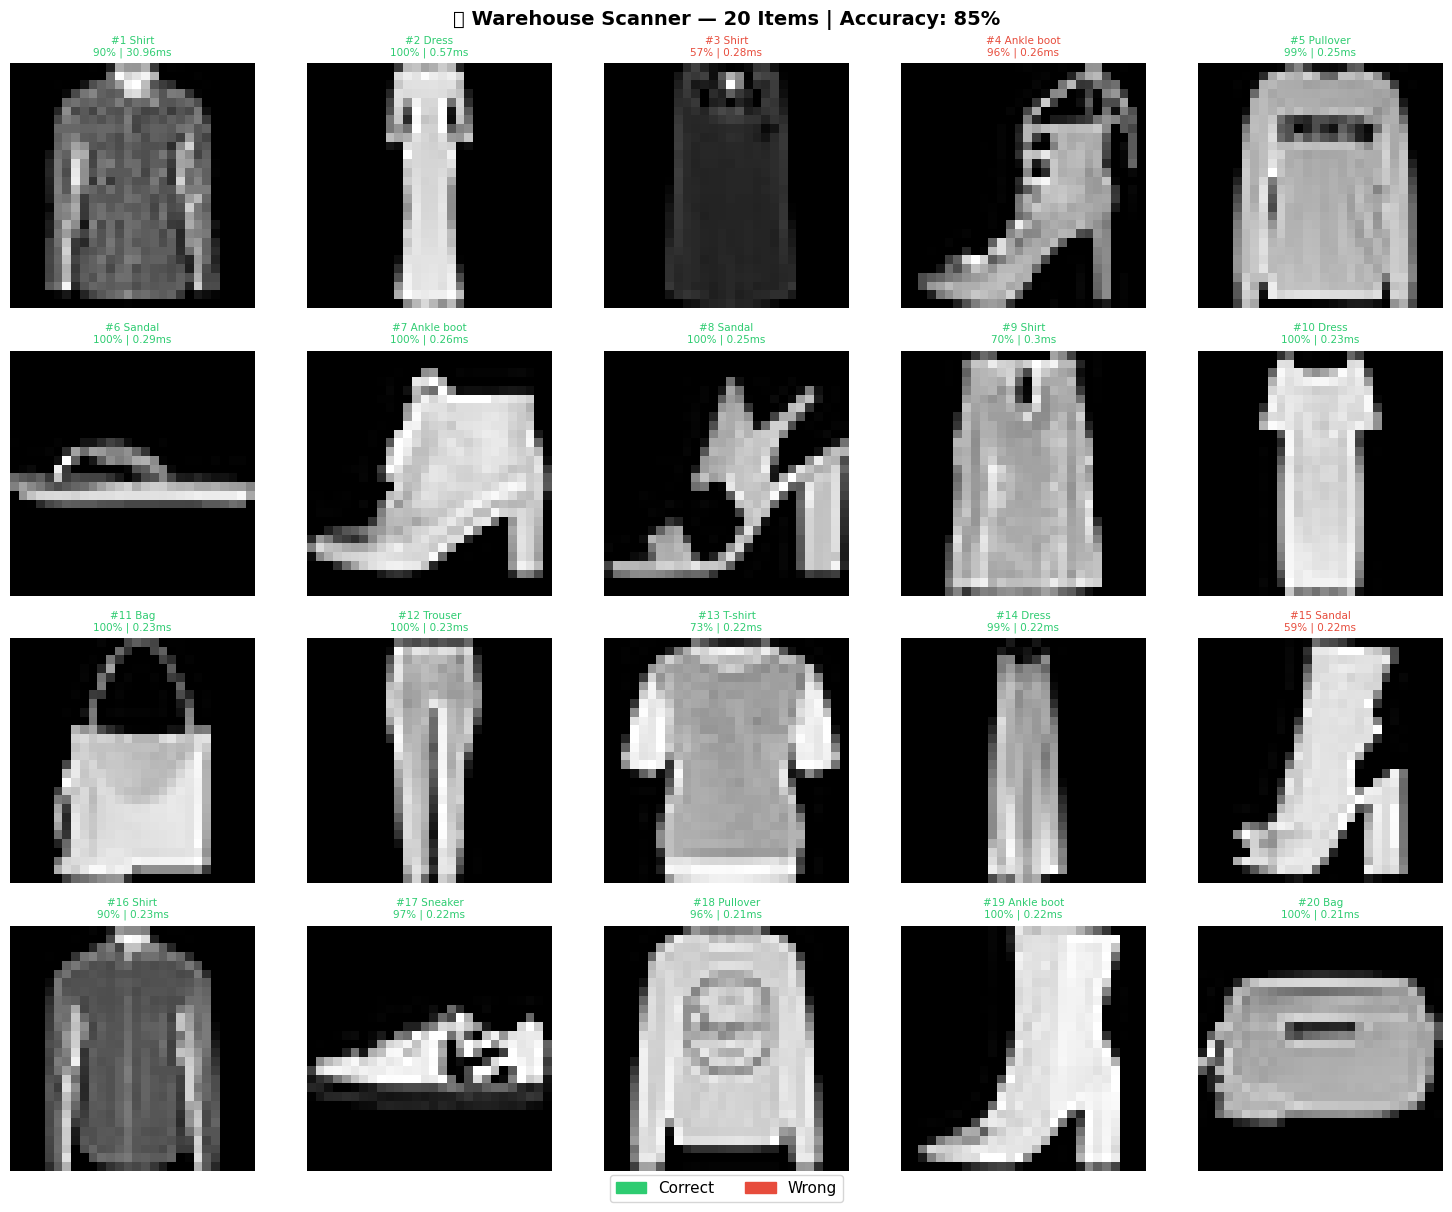

In [4]:
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

for i, (idx, result) in enumerate(zip(belt_indices, results)):
    axes[i].imshow(X_test[idx], cmap="gray")
    color = "#2ecc71" if result["correct"] else "#e74c3c"
    axes[i].set_title(
        f"#{result['item_no']} {result['predicted_label']}\n"
        f"{result['confidence']:.0%} | {result['scan_time_ms']}ms",
        fontsize=7.5, color=color
    )
    axes[i].axis("off")

correct_patch = mpatches.Patch(color="#2ecc71", label="Correct")
wrong_patch   = mpatches.Patch(color="#e74c3c", label="Wrong")
fig.legend(handles=[correct_patch, wrong_patch], loc="lower center",
           ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.02))

plt.suptitle(f"🏭 Warehouse Scanner — 20 Items | Accuracy: {correct/20:.0%}",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("warehouse_scan.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
from datetime import datetime, timezone

scan_batch_id = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
now           = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S")

with sql.connect(server_hostname=host, http_path=http_path, access_token=token) as conn:
    with conn.cursor() as cursor:
        cursor.execute("""
            CREATE TABLE IF NOT EXISTS workspace.default.warehouse_scan_log (
                scan_batch_id    STRING,
                item_no          BIGINT,
                true_label       STRING,
                predicted_label  STRING,
                confidence       DOUBLE,
                correct          BOOLEAN,
                scan_time_ms     DOUBLE,
                scanned_at       TIMESTAMP
            ) USING DELTA
        """)

        rows = ", ".join([
            f"('{scan_batch_id}', {r['item_no']}, '{r['true_label']}', "
            f"'{r['predicted_label']}', {r['confidence']}, {r['correct']}, "
            f"{r['scan_time_ms']}, '{now}')"
            for r in results
        ])
        cursor.execute(f"INSERT INTO workspace.default.warehouse_scan_log VALUES {rows}")

print(f"✅ 20 scan records saved to Databricks!")
print(f"   Batch ID: {scan_batch_id}")


ThriftBackend.attempt_request: Exception: BAD_REQUEST: Sorry, cannot run the resource because you've exhausted your available credits. Please add a payment method to upgrade your account.


RequestError: Error during request to server: BAD_REQUEST: Sorry, cannot run the resource because you've exhausted your available credits. Please add a payment method to upgrade your account.. BAD_REQUEST: Sorry, cannot run the resource because you've exhausted your available credits. Please add a payment method to upgrade your account.

In [6]:
import pandas as pd
from datetime import datetime, timezone

scan_batch_id = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")

results_df = pd.DataFrame(results)
results_df["scan_batch_id"] = scan_batch_id

results_df.to_csv("warehouse_scan_log.csv", index=False)
print(f"✅ Scan log saved locally → warehouse_scan_log.csv")
print(results_df)


✅ Scan log saved locally → warehouse_scan_log.csv
    item_no  true_label predicted_label  confidence  correct  scan_time_ms  \
0         1       Shirt           Shirt      0.9022     True         30.96   
1         2       Dress           Dress      0.9994     True          0.57   
2         3     T-shirt           Shirt      0.5656    False          0.28   
3         4      Sandal      Ankle boot      0.9643    False          0.26   
4         5    Pullover        Pullover      0.9883     True          0.25   
5         6      Sandal          Sandal      1.0000     True          0.29   
6         7  Ankle boot      Ankle boot      1.0000     True          0.26   
7         8      Sandal          Sandal      1.0000     True          0.25   
8         9       Shirt           Shirt      0.6974     True          0.30   
9        10       Dress           Dress      0.9995     True          0.23   
10       11         Bag             Bag      1.0000     True          0.23   
11       12   